In [2]:
from holmes.preprocessing import ColumnsMissingness, MissingnessCorrelation, ColumnsMissingnessVisualizer, RowsMissingnessVisualizer, MissingnessCorrelationVisualizer, MissingnessClusters
import pandas as pd

In [3]:
n = 40

sample_df = pd.DataFrame({
    "customer_id": list(range(1001, 1001 + n)),
    "country": ["US", "DE", "FR", "BR", "IN"] * 8,
    "age": [
        24, 29, None, 31, 42,
        35, None, 28, 39, 26,
        44, 30, 27, None, 33,
        41, 25, 38, None, 36,
        29, 34, 32, 45, None,
        27, 37, 31, 40, 28,
        None, 26, 35, 39, 30,
        43, None, 33, 41, 29,
    ],
    "salary": [
        None, None, None, 62000, None,
        None, None, None, 58000, None,
        None, None, None, 61000, None,
        None, None, None, 60500, None,
        None, None, None, 59000, None,
        None, None, None, 64000, None,
        None, None, None, 60000, None,
        None, None, None, 61500, None,
    ],
    "segment": ["A", "B", "A", "C"] * 10,
    "last_purchase_days": [
        3, 7, 14, None, 10,
        5, 21, 8, 30, None,
        12, 17, 6, 9, 13,
        None, 20, 11, 15, 18,
        4, None, 22, 16, 19,
        2, 25, 27, None, 24,
        26, 23, 29, 28, None,
        1, 32, 31, 33, 34,
    ],
})


In [4]:
from holmes.preprocessing import ColumnsMissingness, RowsMissingness


col_analyzer = ColumnsMissingness(sample_df)
col_viz=ColumnsMissingnessVisualizer(col_analyzer)
rows_analyzer = RowsMissingness(sample_df)
row_viz = RowsMissingnessVisualizer(rows_analyzer)
cor_analyzer = MissingnessCorrelation(sample_df)
cor_vis = MissingnessCorrelationVisualizer(cor_analyzer)
cluster_analyzer = MissingnessClusters(sample_df)

In [ ]:
cluster_analyzer.rows_in(0)

In [9]:
cluster_analyzer.clusters('exact')

,cluster_id,size,rate,n_missing_cols,missing_columns
0,0,23,0.575,1,[salary]
1,1,5,0.125,2,"[age, salary]"
2,2,4,0.100,0,[]
3,3,4,0.100,2,"[salary, last_purchase_days]"
4,4,2,0.050,1,[last_purchase_days]
5,5,2,0.050,1,[age]


(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'left': 'Strongest Missingness Dependencies'}, xlabel="Association strength (r / Cramer's V)">)

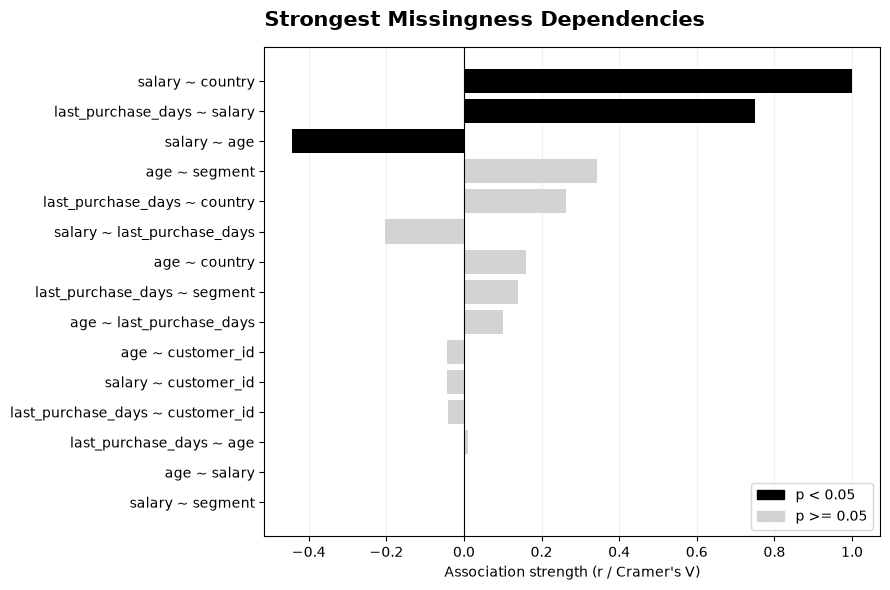

In [13]:
cor_vis.dependence_bar()

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'left': 'Missingness Correlation (co-occurrence)'}>)

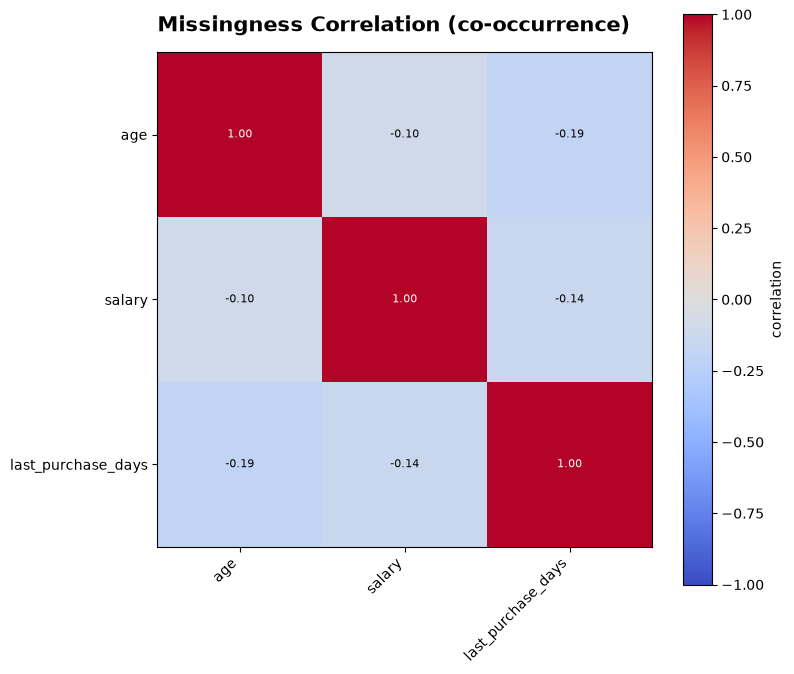

In [12]:
cor_vis.heatmap()

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'left': 'Row Completeness'}, xlabel='Number of missing fields', ylabel='Number of rows'>)

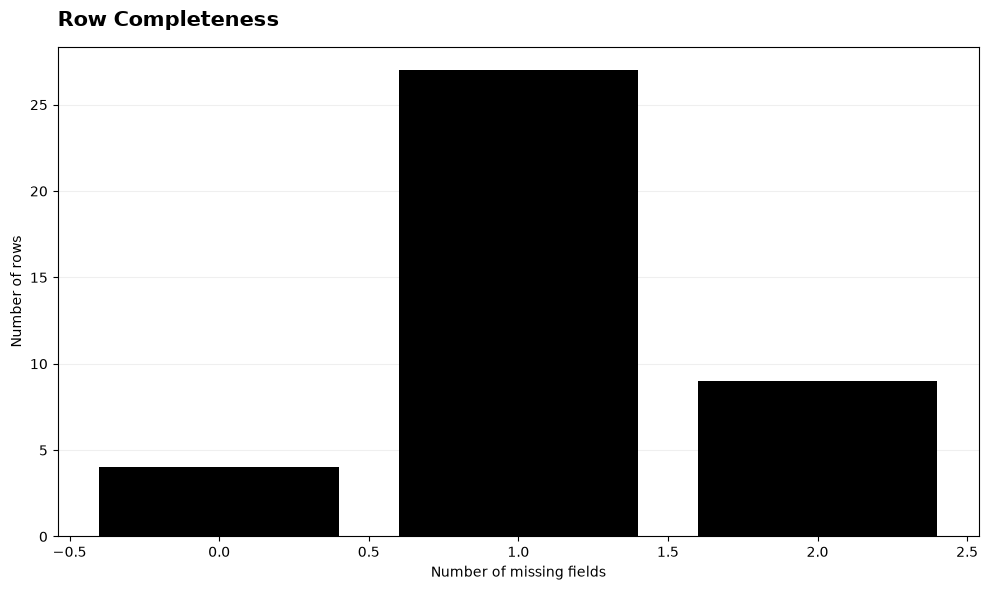

In [8]:
row_viz.completeness()

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'left': 'Row Missingness Distribution'}, xlabel='Missingness rate', ylabel='Number of rows'>)

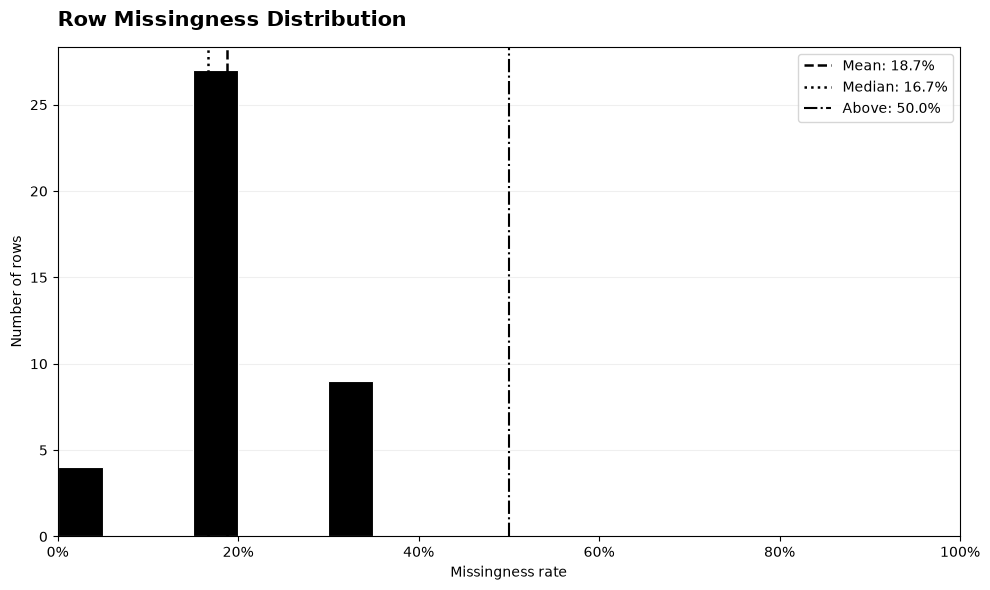

In [10]:
row_viz.distribution(thresholds={"above": 0.5})

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'left': 'Column Missingness'}, xlabel='Missingness rate', ylabel='Column'>)

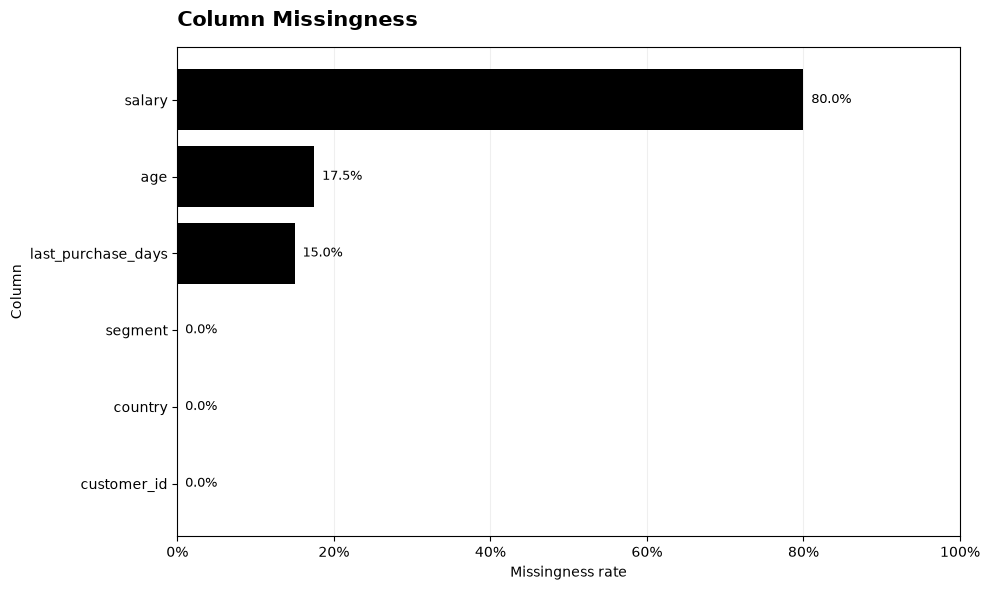

In [6]:
col_viz.rates()

In [3]:
corr = MissingnessCorrelation(sample_df)

In [4]:

corr.missing_missing_corr()

,age,salary,last_purchase_days
age,1.000,-0.099,-0.193
salary,-0.099,1.000,-0.140
last_purchase_days,-0.193,-0.140,1.000


In [5]:
corr.missing_value_correlation()

,missing_column,compared_to,compared_type,statistic,p_value,method
6,salary,country,categorical,1.000,0.0000,cramers_v (chi-square)
7,salary,age,numeric,-0.442,0.0099,point-biserial
13,last_purchase_days,salary,numeric,0.750,0.0321,point-biserial
3,age,segment,categorical,0.342,0.0966,cramers_v (chi-square)
9,salary,last_purchase_days,numeric,-0.204,0.2461,point-biserial
4,age,last_purchase_days,numeric,0.100,0.5733,point-biserial
11,last_purchase_days,country,categorical,0.262,0.6013,cramers_v (chi-square)
14,last_purchase_days,segment,categorical,0.140,0.6756,cramers_v (chi-square)
5,salary,customer_id,numeric,-0.043,0.7907,point-biserial
0,age,customer_id,numeric,-0.043,0.7934,point-biserial
